In [7]:
import numpy as np
import pandas as pd
import openpyxl
from io import StringIO
import os

# Define all specimen IDs to process
specimen_ids = [1,2,3,4,5]  # Add more specimen numbers as needed
#1,2,3,4,5,6,7,8,9,10,11, 12, 13

for ii in specimen_ids:
    print(f"\n--- Processing Specimen {ii} ---")

    # Load main Excel data
    xlsx_fpath = f'1.6_test/1.6_{ii}.xlsx'
    csv_fpath = f'1.6_test/1.6_{ii}.csv'

    if not os.path.exists(xlsx_fpath):
        print(f"File not found: {xlsx_fpath}")
        continue

    # Read the measurement data
    workbook = openpyxl.load_workbook(xlsx_fpath)
    sheetnames = workbook.sheetnames
    data = pd.read_excel(xlsx_fpath, skiprows=1, sheet_name=sheetnames[0])  #[2]
    data.to_csv(csv_fpath, index=None, header=True)
    data = pd.read_csv(csv_fpath, skiprows=1)

    # Extract closest values for each target range (fixed from measurement)
    target_range = np.arange(0.00, 1.04, 0.02)
    closest_indices = [np.abs(data['mm'] - target).idxmin() for target in target_range]
    closest_rows = data.loc[np.unique(closest_indices)]
    closest_rows.index = np.arange(len(closest_rows))  # Reset index

    # Load reference DISPLACEMENT_Y max from pt_0
    ref_file = f'20260203_UC0.8_1.6_DIC/{ii}/live_plot_pt_0.txt'
    if os.path.exists(ref_file):
        with open(ref_file, 'r') as file:
            ref_lines = file.readlines()[1:]
        ref_str = ''.join(ref_lines)
        ref_io = StringIO(ref_str)
        ref_df = pd.read_csv(ref_io, delimiter=',')
        ref_max_dy = ref_df['DISPLACEMENT_Y'].max()
    else:
        print(f"Reference file not found: {ref_file}")
        ref_max_dy = 1.0  # Fallback to avoid division by zero

    # Process each point file
    pfad = list(range(9))  # Points from 0 to 8
    all_data = []

    for i in pfad:
        file_path = f'20260203_UC0.8_1.6_DIC/{ii}/live_plot_pt_{i}.txt'
        output_path = f'20260203_UC0.8_1.6_DIC/{ii}/live_plot_pt_{i}.csv'

        if os.path.exists(file_path):
            with open(file_path, 'r') as file:
                lines = file.readlines()[1:]  # Skip header

            data_str = ''.join(lines)
            data_io = StringIO(data_str)
            df = pd.read_csv(data_io, delimiter=',')

            # Keep only displacement columns
            df = df[['DISPLACEMENT_X', 'DISPLACEMENT_Y']].copy()
            df['times'] = np.arange(0, len(df))

            # Interpolate 'endsh' and 'P' to match the row count of displacement data
            n_rows = len(df)
            interp_index = np.linspace(0, len(closest_rows) - 1, n_rows)
            df['endsh'] = np.interp(interp_index, np.arange(len(closest_rows)), closest_rows['mm'])
            df['P'] = np.interp(interp_index, np.arange(len(closest_rows)), closest_rows['N'])

            # Use ref_max_dy from pt_0 to compute ratio
            df['ratio'] = df['DISPLACEMENT_X'] / ref_max_dy

            # Save CSV
            df.to_csv(output_path, index=False)

            # Add identifier and store for final Excel
            df['Point'] = f'pt_{i}'
            all_data.append(df)

            print(f"pt_{i} | DY max (pt_0): {ref_max_dy:.4f} | ratio range: {df['ratio'].min():.4f} - {df['ratio'].max():.4f}")
        else:
            print(f"File not found: {file_path}")

    # Save combined Excel file
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        final_excel_path = f'20260203_UC0.8_1.6_DIC_{ii}.xlsx'
        final_df.to_excel(final_excel_path, index=False)
        print(f"✅ Saved Excel: {final_excel_path}")
    else:
        print(f"⚠️ No valid data processed for specimen {ii}")


--- Processing Specimen 1 ---
Reference file not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_0.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_0.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_1.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_2.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_3.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_4.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_5.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_6.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_7.txt
File not found: 20260203_UC0.8_1.6_DIC/1/live_plot_pt_8.txt
⚠️ No valid data processed for specimen 1

--- Processing Specimen 2 ---
pt_0 | DY max (pt_0): 71.1127 | ratio range: -0.4517 - -0.2776
pt_1 | DY max (pt_0): 71.1127 | ratio range: -1.2839 - -0.2505
pt_2 | DY max (pt_0): 71.1127 | ratio range: -1.5486 - -0.2166
pt_3 | DY max (pt_0): 71.1127 | ratio range: -0.8096 - -0.1824
pt_4 | DY max (pt_0): 71.1127 | ra

File not found: 20260203_UC0.8_1.6_DIC_1.xlsx


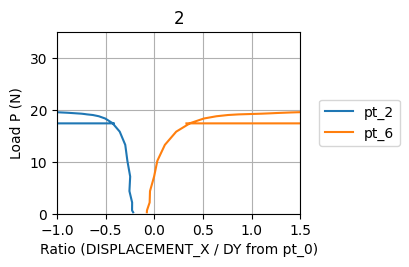

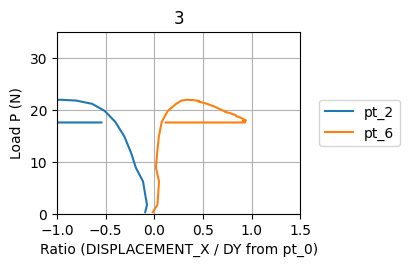

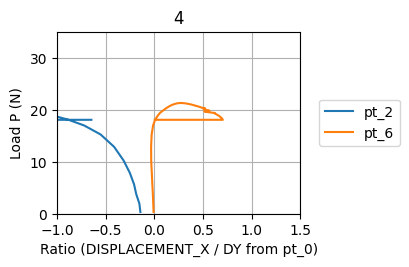

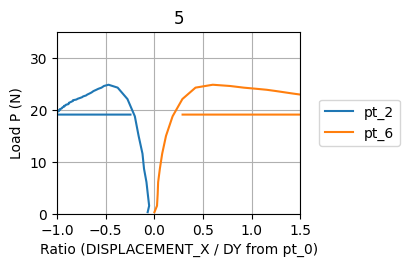

File not found: 20260203_UC0.8_1.6_DIC_6.xlsx


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the specimen IDs you want to plot
specimen_ids = [1,2,3,4,5,6]  # Add or change as needed
#1,2,3,4,5,6,7,8,9,10,11, 12, 13,14,15
for ii in specimen_ids:
    file_path = f'20260203_UC0.8_1.6_DIC_{ii}.xlsx'

    try:
        final_df = pd.read_excel(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        continue

    # Create a new figure for each specimen
    plt.figure(figsize=(3.14, 2.36))

    # Plot each point pt_0 to pt_8
    for i in [2,6]:#range(9)
        subset = final_df[final_df["Point"] == f"pt_{i}"]
        plt.plot(subset["ratio"], subset["P"], label=f"pt_{i}")

    plt.ylim(0, 35)
    plt.xlim(-1, 1.5)
    plt.title(str(ii))
    plt.ylabel("Load P (N)")
    plt.xlabel("Ratio (DISPLACEMENT_X / DY from pt_0)")
    plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    plt.grid(True)
    #plt.tight_layout()

    # Optional: save the figure
    plt.savefig(f'Ratio_vs_P_Specimen_{ii}.png', dpi=300, bbox_inches='tight')
    plt.show()


Saved curve data -> 20260203_UC0.8_1.4_DIC_shifted2.xlsx


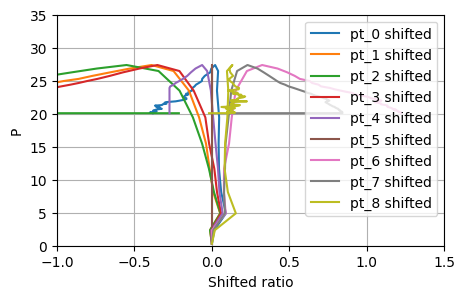

Saved curve data -> 20260203_UC0.8_1.4_DIC_shifted5.xlsx


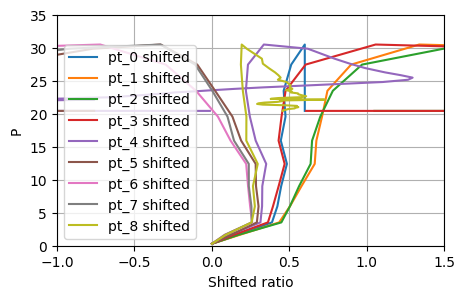

Saved curve data -> 20260203_UC0.8_1.4_DIC_shifted6.xlsx


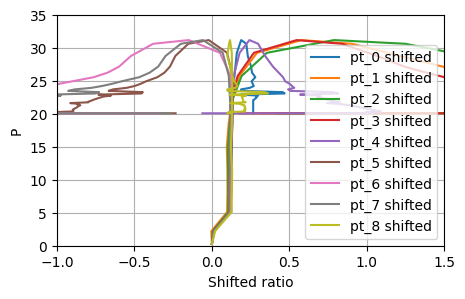

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -------- CONFIG --------
base_path = ""
file_template = "20260203_UC0.8_1.4_DIC_{}.xlsx"
points= [f'pt_{i}' for i in range(9)] #[f'pt_{i}' for i in [2,6]]
p_col = 'P'
x_col = 'ratio'

# -------- HELPER FUNCTION --------
def x_at_p0(sub_df, p_col='P', x_col='ratio'):
    sub = sub_df[[p_col, x_col]].astype(float).copy()
    sub = sub.sort_values(p_col).reset_index(drop=True)

    P = sub[p_col].values
    X = sub[x_col].values

    z_mask = np.isclose(P, 0.0, atol=1e-9)
    if z_mask.any():
        return float(X[z_mask.argmax()])

    signs = np.sign(P)
    idx = np.where(np.diff(signs) != 0)[0]

    if len(idx) > 0:
        j = idx[0]
        P1, P2 = P[j], P[j+1]
        X1, X2 = X[j], X[j+1]
        frac = (0 - P1) / (P2 - P1)
        return float(X1 + frac * (X2 - X1))

    return float(X[np.argmin(np.abs(P))])


# -------- PROCESS --------
for i in [1,2,3,4,5,6]:

    file_name = file_template.format(i)
    file_path = os.path.join(base_path, file_name)

    if not os.path.exists(file_path):
        continue

    df = pd.read_excel(file_path)
    df = df.dropna(subset=[p_col, x_col, 'Point']).reset_index(drop=True)

    # find shift for selected points only
    shifts = {}
    for pt in points:
        sub = df[df['Point'] == pt]
        shifts[pt] = x_at_p0(sub) if not sub.empty else np.nan

    df['ratio_shifted'] = df.apply(
        lambda r: r[x_col] - shifts.get(r['Point'], np.nan),
        axis=1
    )

    # ===============================
    # SAVE ONLY RED + ORANGE CURVES
    # ===============================
    curve_df = df[df['Point'].isin(points)][['Point', 'ratio_shifted', 'P']]

    out_path = os.path.join(base_path,
                            f"20260203_UC0.8_1.4_DIC_shifted{i}.xlsx")

    curve_df.to_excel(out_path, index=False)

    print("Saved curve data ->", out_path)

    # ===============================
    # PLOT
    # ===============================
    plt.figure(figsize=(5, 3))

    for pt in points:
        sub = df[df['Point'] == pt]
        plt.plot(sub['ratio_shifted'], sub['P'], label=f"{pt} shifted")

    plt.ylim(0, 35)
    plt.xlim(-1, 1.5)
    
    #plt.axvline(0)
    plt.xlabel('Shifted ratio')
    plt.ylabel('P')
    plt.legend()
    plt.grid(True)

    fig_path = os.path.join(base_path, f"UC_1.4_UC_Ri_shifted_{i}.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()


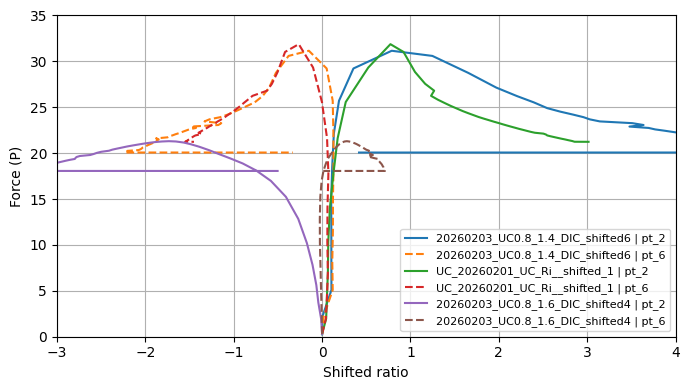

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -------- CONFIG --------
base_path = ""   # e.g. r"D:\your\folder"
files = [
    #"results/UC_0.8_perfect_shifted_1.xlsx",
    "results/20260203_UC0.8_1.4_DIC_shifted6.xlsx",
    "results/UC_20260201_UC_Ri__shifted_1.xlsx",
    "results/20260203_UC0.8_1.6_DIC_shifted4.xlsx"
    
]

points_to_plot = ["pt_2", "pt_6"]   # we'll also match pt-2/pt-6 automatically
p_col = "P"
point_col = "Point"

# prefer these x columns (first found will be used)
x_candidates = ["ratio_shifted", "ratio shifted", "ratio", "Ratio", "RATIO"]

# -------- HELPER FUNCTION (shift at P=0) --------
def x_at_p0(sub_df, p_col="P", x_col="ratio"):
    sub = sub_df[[p_col, x_col]].astype(float).copy()
    sub = sub.sort_values(p_col).reset_index(drop=True)

    P = sub[p_col].values
    X = sub[x_col].values

    z_mask = np.isclose(P, 0.0, atol=1e-9)
    if z_mask.any():
        return float(X[z_mask.argmax()])

    signs = np.sign(P)
    idx = np.where(np.diff(signs) != 0)[0]
    if len(idx) > 0:
        j = idx[0]
        P1, P2 = P[j], P[j + 1]
        X1, X2 = X[j], X[j + 1]
        frac = (0 - P1) / (P2 - P1)
        return float(X1 + frac * (X2 - X1))

    return float(X[np.argmin(np.abs(P))])

def normalise_point(s: str) -> str:
    # makes pt-2 and pt_2 consistent
    return str(s).strip().replace("-", "_")

# -------- LOAD + PLOT --------
plt.figure(figsize=(7, 4))

for fname in files:
    fpath = os.path.join(base_path, fname)
    if not os.path.exists(fpath):
        print("Missing:", fpath)
        continue

    df = pd.read_excel(fpath)
    df.columns = [c.strip() for c in df.columns]  # remove accidental spaces in headers

    if point_col not in df.columns or p_col not in df.columns:
        print(f"Skip {fname} (missing '{point_col}' or '{p_col}'). Columns:", df.columns.tolist())
        continue

    # normalise Point names
    df[point_col] = df[point_col].map(normalise_point)

    # find which x column exists
    x_col = next((c for c in x_candidates if c in df.columns), None)
    if x_col is None:
        print(f"Skip {fname} (no ratio column found). Columns:", df.columns.tolist())
        continue

    # keep only needed cols and numeric
    df = df.dropna(subset=[p_col, x_col, point_col]).copy()
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    df = df.dropna(subset=[p_col, x_col])

    # ensure we have a 'ratio_shifted' column for plotting
    if x_col == "ratio_shifted":
        df["ratio_shifted"] = df["ratio_shifted"]
    else:
        # create ratio_shifted per file using pt_2 (or first available point) shift at P=0
        # (you can change this rule if you want the shift based on pt_6 instead)
        pt_for_shift = points_to_plot[0]
        sub_shift = df[df[point_col] == pt_for_shift]
        if sub_shift.empty:
            sub_shift = df  # fallback: use all rows
        shift = x_at_p0(sub_shift, p_col=p_col, x_col=x_col)
        df["ratio_shifted"] = df[x_col] - shift

    file_label = os.path.splitext(os.path.basename(fname))[0]

    # plot pt_2 and pt_6
    for pt in points_to_plot:
        sub = df[df[point_col] == pt]
        if sub.empty:
            print(f"{pt} not found in {fname}")
            continue

        ls = "-" if pt == "pt_2" else "--"
        plt.plot(sub["ratio_shifted"], sub[p_col], ls, label=f"{file_label} | {pt}")

plt.ylim(0, 35)
plt.xlim(-3, 4)
plt.xlabel("Shifted ratio")
plt.ylabel("Force (P)")
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


/tmp/ipykernel_53/489713318.py:132: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


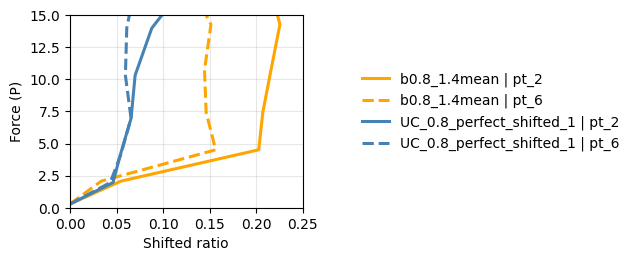

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -------- CONFIG --------
base_path = ""   # e.g. r"D:\your\folder"
files = [
    "b0.8_1.4mean.xlsx",
    "results/UC_0.8_perfect_shifted_1.xlsx"
    #"results/20260203_UC0.8_1.4_DIC_shifted6.xlsx",
    
    #"results/UC_20250313_UC_Ri_shifted_curves_only_1.xlsx",  #UC_20260201_UC_Ri__shifted_1
    #"results/20260203_UC0.8_1.6_DIC_shifted4.xlsx"
    #UC_20250313_UC_Ri_shifted_curves_only_3
    
]

points_to_plot = ["pt_2", "pt_6"]  #"pt_2", "pt_6"  # we'll also match pt-2/pt-6 automatically
p_col = "P"
point_col = "Point"

# prefer these x columns (first found will be used)
x_candidates = ["ratio_shifted", "ratio shifted", "ratio", "Ratio", "RATIO"]

# -------- HELPER FUNCTION (shift at P=0) --------
def x_at_p0(sub_df, p_col="P", x_col="ratio"):
    sub = sub_df[[p_col, x_col]].astype(float).copy()
    sub = sub.sort_values(p_col).reset_index(drop=True)

    P = sub[p_col].values
    X = sub[x_col].values

    z_mask = np.isclose(P, 0.0, atol=1e-9)
    if z_mask.any():
        return float(X[z_mask.argmax()])

    signs = np.sign(P)
    idx = np.where(np.diff(signs) != 0)[0]
    if len(idx) > 0:
        j = idx[0]
        P1, P2 = P[j], P[j + 1]
        X1, X2 = X[j], X[j + 1]
        frac = (0 - P1) / (P2 - P1)
        return float(X1 + frac * (X2 - X1))

    return float(X[np.argmin(np.abs(P))])

def normalise_point(s: str) -> str:
    # makes pt-2 and pt_2 consistent
    return str(s).strip().replace("-", "_")



# -------- LOAD + PLOT --------
plt.figure(figsize=(3, 2.5))
#plt.figure(figsize=(3.5, 2.5))
#colours = plt.rcParams['axes.prop_cycle'].by_key()['color']  # safe colour list
colours = [ "orange","steelblue"]

for file_idx, fname in enumerate(files):

    fpath = os.path.join(base_path, fname)
    if not os.path.exists(fpath):
        print("Missing:", fpath)
        continue

    df = pd.read_excel(fpath)
    df.columns = [c.strip() for c in df.columns]

    if point_col not in df.columns or p_col not in df.columns:
        continue

    df[point_col] = df[point_col].map(normalise_point)

    x_col = next((c for c in x_candidates if c in df.columns), None)
    if x_col is None:
        continue

    df = df.dropna(subset=[p_col, x_col, point_col]).copy()
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")

    # ---- ensure shifted ----
    if x_col != "ratio_shifted":
        shift = x_at_p0(df, p_col=p_col, x_col=x_col)
        df["ratio_shifted"] = df[x_col] - shift
    else:
        df["ratio_shifted"] = df["ratio_shifted"]

    file_label = os.path.splitext(os.path.basename(fname))[0]

    # ✅ same colour per file
    colour = colours[file_idx % len(colours)]

    style_map = {
        "pt_2": dict(ls="-" ),
        "pt_6": dict(ls="--"),
    }

    for pt in points_to_plot:
        sub = df[df[point_col] == pt]
        if sub.empty:
            continue

        plt.plot(
            sub["ratio_shifted"],
            sub[p_col],
            color=colour,
            linestyle=style_map[pt]["ls"],
            #marker=style_map[pt]["marker"],
            #markevery=15,
            linewidth=2.2,
            #markersize=4,
            label=f"{file_label} | {pt}"
        )

# -------- STYLE --------
#plt.ylim(0, 35)
#plt.xlim(-1.0, 1.5)
plt.ylim(0, 15)
plt.xlim(-0, 0.25)
plt.xlabel("Shifted ratio")
plt.ylabel("Force (P)")
plt.grid(True, alpha=0.3)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.2, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig("combined_curves.png", dpi=600)
plt.show()


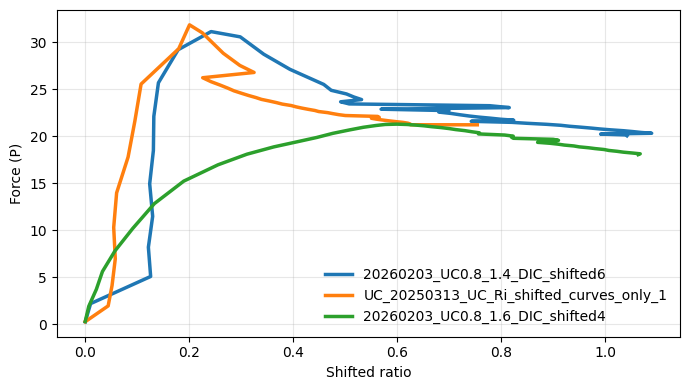

In [23]:
# -------- LOAD + PLOT (ONLY pt_4) --------
plt.figure(figsize=(7, 4))

target_point = "pt_4"
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

for file_idx, fname in enumerate(files):

    fpath = os.path.join(base_path, fname)
    if not os.path.exists(fpath):
        print("Missing:", fpath)
        continue

    df = pd.read_excel(fpath)
    df.columns = [c.strip() for c in df.columns]

    if point_col not in df.columns or p_col not in df.columns:
        continue

    df[point_col] = df[point_col].map(normalise_point)

    x_col = next((c for c in x_candidates if c in df.columns), None)
    if x_col is None:
        continue

    df = df.dropna(subset=[p_col, x_col, point_col]).copy()
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")

    # ---- ensure shifted ----
    if x_col != "ratio_shifted":
        shift = x_at_p0(df[df[point_col] == target_point], p_col=p_col, x_col=x_col)
        df["ratio_shifted"] = df[x_col] - shift
    else:
        df["ratio_shifted"] = df["ratio_shifted"]

    sub = df[df[point_col] == target_point]
    if sub.empty:
        print(f"{target_point} not found in {fname}")
        continue

    colour = colours[file_idx % len(colours)]
    label = os.path.splitext(os.path.basename(fname))[0]

    plt.plot(
        sub["ratio_shifted"],
        sub[p_col],
        color=colour,
        linewidth=2.5,
        label=label
    )

# -------- STYLE --------
#plt.ylim(0, 20)
#plt.xlim(-0.1, 0.3)
#plt.ylim(0, 30)
#plt.xlim(-1.0, 1.5)
plt.xlabel("Shifted ratio")
plt.ylabel("Force (P)")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("combined_pt4_curves.png", dpi=600)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel file
# mean_P_vs_ratio_with_time_3.xlsx
# mean_P_vs_ratio_with_time_9_8_7.xlsx
# mean_P_vs_ratio_with_time_13_10_1.xlsx
# mean_P_vs_ratio_with_time_15_11_6_5_2.xlsx

file_path = "mean_P_vs_ratio_with_time_15_11_6_5_2.xlsx"
df = pd.read_excel(file_path)

# Rename column if necessary to match script
if 'time' in df.columns:
    df = df.rename(columns={'time': 'times'})

# Create subplot
fig, axs = plt.subplots(1, 8, figsize=(14, 5), sharex=False, sharey=True)
axs = axs.flatten()

# Define time steps to plot
selected_times = [2, 5, 10, 15, 17, 18, 28,49]

for i, times_value in enumerate(selected_times):
    ax = axs[i]
    filtered_df = df[df["times"] == times_value]
    unique_points = filtered_df["Point"].unique()
    plot_data = []

    for pt in unique_points:
        pt_data = filtered_df[filtered_df["Point"] == pt]
        if not pt_data.empty:
            ratio = pt_data["ratio_mean"].values[0]
            index = int(pt.split("_")[1])
            y_value = 49 - (49 / (len(unique_points) - 1)) * index
            plot_data.append({"Point": pt, "ratio_mean": ratio, "y": y_value})

    plot_df = pd.DataFrame(plot_data)

    P_value = filtered_df["P_mean"].mean() if not filtered_df.empty else None

    ax.scatter(plot_df["ratio_mean"], plot_df["y"], color='black', s=12)
    ax.plot(plot_df["ratio_mean"], plot_df["y"], linestyle="dashed", color='blue')

    for _, row in plot_df.iterrows():
        ax.text(row["ratio_mean"], row["y"], row["Point"], fontsize=10, verticalalignment='center', horizontalalignment='left')

    ax.plot([0, 0], [0, 50], color="black", linestyle="dotted")

    delta = 1 / 50 * times_value
    delta_str = f"$\\Delta$ = {delta:.2f}"
    if P_value is not None:
        title_str = f"{delta_str} mm\nP = {P_value:.2f} N"
    else:
        title_str = f"{delta_str}"
    ax.set_title(title_str, fontsize=10)

    if i < 2:
        ax.set_xlim(-0.05, 0.05)
        ax.tick_params(axis='x', colors='red')
    elif i in [2, 3]:
        ax.set_xlim(-1, 1)
        ax.tick_params(axis='x', colors='blue')
    else:
        ax.set_xlim(-3, 3)

    ax.set_ylim(0, 50)
    ax.xaxis.set_tick_params(rotation=45)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)

# Common labels
fig.text(0.5, 0.04, "Displacement in y-direction (mm)", ha='center', fontsize=12)
fig.text(0.04, 0.5, "Cross length (mm)", va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#13, 10, 1
#9,8,7
#15,11,6,5,2
#3
# Files and points to process
file_indices = [13, 10, 1]
points = [f'pt_{i}' for i in range(9)]
selected_points = ['pt_2', 'pt_6']

# Load all available files
dfs = {}
for i in file_indices:
    file_path = f"UC_20250313_UC_Ri__shifted_{i}.xlsx"
    dfs[f'df_file{i}'] = pd.read_excel(file_path)

# Prepare structure to hold point-wise data
point_data = {pt: [] for pt in points}

# Extract first 51 rows per point from each file
for df in dfs.values():
    for pt in points:
        subset = df[df['Point'] == pt][['P', 'ratio_shifted']]
        if len(subset) >= 51:
            point_data[pt].append(subset.iloc[:51].reset_index(drop=True))

# Compute mean and 95% CI across files
mean_combined = []
for pt, data_list in point_data.items():
    if pt not in selected_points:
        continue
    if data_list:
        data_stack = np.stack([d[['P', 'ratio_shifted']].values for d in data_list])
        mean_vals = np.mean(data_stack, axis=0)
        std_vals = np.std(data_stack, axis=0, ddof=1)
        ci_vals = 1.96 * std_vals / np.sqrt(len(data_list))
        time = np.arange(51)

        df_mean = pd.DataFrame({
            'times': time,
            'P_mean': mean_vals[:, 0],
            'P_CI': ci_vals[:, 0],
            'ratio_mean': mean_vals[:, 1],
            'ratio_CI': ci_vals[:, 1],
            'Point': pt
        })
        mean_combined.append(df_mean)

# Combine all mean data
df_mean_combined = pd.concat(mean_combined, ignore_index=True)

# Save to Excel
#output_path = "/mnt/data/mean_P_vs_ratio_with_CI_pt2_pt6_files_7_8_9.xlsx"
#df_mean_combined.to_excel(output_path, index=False)

# Plot with 95% CI
plt.figure(figsize=(6, 4))
for pt in selected_points:
    subset = df_mean_combined[df_mean_combined['Point'] == pt]
    plt.plot(subset['ratio_mean'], subset['P_mean'], label=pt)
    plt.fill_between(subset['ratio_mean'],
                     subset['P_mean'] - subset['P_CI'],
                     subset['P_mean'] + subset['P_CI'],
                     alpha=0.2)

plt.ylim(0, 120)
plt.xlim(-3, 3)
plt.title("Mean P vs. Ratio with 95% CI (pt_2 & pt_6)")
plt.xlabel("Displacement (mean) mm")
plt.ylabel("P (mean) N")
plt.legend(title="Point")
plt.grid(True)
plt.tight_layout()
plt.show()

output_path